conda activate ai    떠 있으면 또 안해도 됨
pip install ipykernel

In [1]:
import torch
print(torch.cuda.is_available())
if torch.cuda.is_available():
    print(torch.cuda.get_device_name(0))

True
NVIDIA GeForce RTX 3060


In [2]:
# 데이터를 불러오고 살펴보기 위한 pandas 라이브러리를 import 
import pandas as pd

# train 이라는 객체에 'train.csv' 파일을 할당 해 줌
train  = pd.read_csv('train.csv')

In [3]:
# train 데이터의 상위 5개 행을 출력
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000


In [4]:
# train 데이터의 전체적인 정보를 요약해서 보여줍니다.
train.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1216553 entries, 0 to 1216552
Data columns (total 13 columns):
 #   Column                  Non-Null Count    Dtype  
---  ------                  --------------    -----  
 0   transaction_id          1216553 non-null  int64  
 1   apartment_id            1216553 non-null  int64  
 2   city                    1216553 non-null  object 
 3   dong                    1216553 non-null  object 
 4   jibun                   1216553 non-null  object 
 5   apt                     1216553 non-null  object 
 6   addr_kr                 1216553 non-null  object 
 7   exclusive_use_area      1216553 non-null  float64
 8   year_of_completion      1216553 non-null  int64  
 9   transaction_year_month  1216553 non-null  int64  
 10  transaction_date        1216553 non-null  object 
 11  floor                   1216553 non-null  int64  
 12  transaction_real_price  1216553 non-null  int64  
dtypes: float64(1), int64(6), object(6)
memory usage: 120.7+ M

In [5]:
# 각 컬럼별 결측값의 개수를 출력해줍니다.
train.isnull().sum()

transaction_id            0
apartment_id              0
city                      0
dong                      0
jibun                     0
apt                       0
addr_kr                   0
exclusive_use_area        0
year_of_completion        0
transaction_year_month    0
transaction_date          0
floor                     0
transaction_real_price    0
dtype: int64

In [6]:
# 수치형 컬럼의 통계를 요약해 출력해 줍니다. 
train.describe()

,transaction_id,apartment_id,exclusive_use_area,year_of_completion,transaction_year_month,floor,transaction_real_price
count,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06,1.216553e+06
mean,6.091530e+05,6.299685e+03,7.816549e+01,1.998297e+03,2.012984e+05,9.343291e+00,3.822769e+04
std,3.526198e+05,3.581169e+03,2.915113e+01,8.941347e+00,2.905732e+02,6.606500e+00,3.104898e+04
min,0.000000e+00,0.000000e+00,9.260000e+00,1.961000e+03,2.008010e+05,-4.000000e+00,1.000000e+02
25%,3.041380e+05,3.345000e+03,5.976000e+01,1.993000e+03,2.010100e+05,4.000000e+00,1.900000e+04
50%,6.082760e+05,5.964000e+03,8.241000e+01,1.999000e+03,2.013120e+05,8.000000e+00,3.090000e+04
75%,9.124140e+05,9.436000e+03,8.497000e+01,2.005000e+03,2.015110e+05,1.300000e+01,4.700000e+04
max,1.234827e+06,1.265800e+04,4.243200e+02,2.017000e+03,2.017110e+05,8.000000e+01,8.200000e+05


In [7]:
# 점주형 컬럼의 통계를 요약해 출력해줍니다.
train.describe(include=['object'])

,city,dong,jibun,apt,addr_kr,transaction_date
count,1216553,1216553,1216553,1216553,1216553,1216553
unique,2,473,8961,10440,12533,6
top,서울특별시,상계동,176-30,현대,용호동 944 오륙도에스케이뷰,11~20
freq,742285,29346,6594,13154,3220,408385


In [8]:
train['city'].value_counts()

city
서울특별시    742285
부산광역시    474268
Name: count, dtype: int64

In [9]:
train['city'] == '부산광역시'

0          False
1          False
2          False
3          False
4          False
           ...  
1216548     True
1216549     True
1216550     True
1216551     True
1216552     True
Name: city, Length: 1216553, dtype: bool

In [10]:
train[train['city'] == '부산광역시']

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [11]:
train.loc[train['city']=='부산광역시',:]

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
650921,650921,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),57.0900,1998,200801,1~10,4,7900
650922,650922,2939,부산광역시,영주동,587,도경오벨리스,영주동 587 도경오벨리스,84.9700,2005,200801,1~10,12,13000
650923,650923,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.8600,1997,200801,11~20,7,12400
650924,650924,3310,부산광역시,영주동,160,동아(160-0),영주동 160 동아(160-0),84.7200,1998,200801,11~20,14,10600
650925,650925,1704,부산광역시,영주동,161,금호,영주동 161 금호,84.5900,1997,200801,21~31,5,10000
...,...,...,...,...,...,...,...,...,...,...,...,...,...
1216548,1234823,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,59.8245,2012,201711,11~20,3,22000
1216549,1234824,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,7,30750
1216550,1234825,9578,부산광역시,정관읍 용수리,1387,정관 동일스위트1차,정관읍 용수리 1387 정관 동일스위트1차,84.9923,2012,201711,21~30,9,29500
1216551,1234826,9586,부산광역시,정관읍 용수리,1364,정관신도시롯데캐슬,정관읍 용수리 1364 정관신도시롯데캐슬,101.7400,2008,201711,21~30,7,26700


In [12]:
train.loc[train['city']=='부산광역시',['year_of_completion','transaction_year_month']]

,year_of_completion,transaction_year_month
650921,1998,200801
650922,2005,200801
650923,1997,200801
650924,1998,200801
650925,1997,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [13]:
train.iloc[:,[8,9]]

,year_of_completion,transaction_year_month
0,2002,200801
1,1973,200801
2,2007,200801
3,2003,200801
4,2004,200801
...,...,...
1216548,2012,201711
1216549,2012,201711
1216550,2012,201711
1216551,2008,201711


In [14]:
train.iloc[9:20,[8,9]]

,year_of_completion,transaction_year_month
9,2006,200801
10,2004,200801
11,2002,200801
12,2003,200801
13,1999,200801
14,1999,200801
15,1999,200801
16,1999,200801
17,1968,200801
18,1999,200801


In [15]:
# 웹 파이썬 
# import micropip
# await micropip.install('seaborn')
# ! : 터미널에서 실행
# !pip install seaborn
# 설치 되어있었음 

In [16]:
# 파이썬 warning 무시
import warnings
warnings.simplefilter(action='ignore', category=FutureWarning)

# 시각화를 위한 라이브러리
# import matplotlib.font_manager as fm  # 폰트매니저

# 한글 폰트를 사용하기 위한 코드
# fe = fm.FontEntry(fname='NotoSansKR-Regular.otf','NotoSansKR')
# fm.fontManager.ttflist.insert(0,fe)   # 폰트 matplotlib 에 추가하는 (맨앞에 추가)
# plt.rc('font', family = 'NotoSansKR')

# 해당 폰트가 없어 윈도우에서 지원하는 폰트 사용 
import matplotlib.pyplot as plt

plt.rc('font', family='Malgun Gothic')
plt.rc('axes', unicode_minus=False)

In [17]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

plt.style.use("fivethirtyeight")

In [18]:
train = pd.read_csv('train.csv')

In [19]:
train.head(2)

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000


In [20]:
# transaction_year_month 에서 연도와 월을 분리
train['year'] = train['transaction_year_month'].astype(str).str[:4].astype(int)
train['month'] = train['transaction_year_month'].astype(str).str[:4].astype(int)

In [21]:
train.head()

,transaction_id,apartment_id,city,dong,jibun,apt,addr_kr,exclusive_use_area,year_of_completion,transaction_year_month,transaction_date,floor,transaction_real_price,year,month
0,0,7622,서울특별시,신교동,6-13,신현(101동),신교동 6-13 신현(101동),84.82,2002,200801,21~31,2,37500,2008,2008
1,1,5399,서울특별시,필운동,142,사직파크맨션,필운동 142 사직파크맨션,99.17,1973,200801,1~10,6,20000,2008,2008
2,2,3578,서울특별시,필운동,174-1,두레엘리시안,필운동 174-1 두레엘리시안,84.74,2007,200801,1~10,6,38500,2008,2008
3,3,10957,서울특별시,내수동,95,파크팰리스,내수동 95 파크팰리스,146.39,2003,200801,11~20,15,118000,2008,2008
4,4,10639,서울특별시,내수동,110-15,킹스매너,내수동 110-15 킹스매너,194.43,2004,200801,21~31,3,120000,2008,2008


In [22]:
train['transaction_date'].value_counts()

transaction_date
11~20    408385
1~10     391715
21~31    250588
21~30    134017
21~28     22199
21~29      9649
Name: count, dtype: int64

In [23]:
# transaction_date에서 21 ~ 31 , 21 ~ 30, 21~ 28 , 21~29 에 해당하는 값을 21~31로 변환해봅시다.
train.loc[(train['transaction_date'] == '21~30') | (train['transaction_date'] == '21~28') | (train['transaction_date'] == '21~29'),'transaction_date'] = '21~31'

In [24]:
train['transaction_date'].value_counts()

transaction_date
21~31    416453
11~20    408385
1~10     391715
Name: count, dtype: int64

In [25]:
# pie chart 
seoul_busan = train['city'].value_counts()
seoul_busan

city
서울특별시    742285
부산광역시    474268
Name: count, dtype: int64

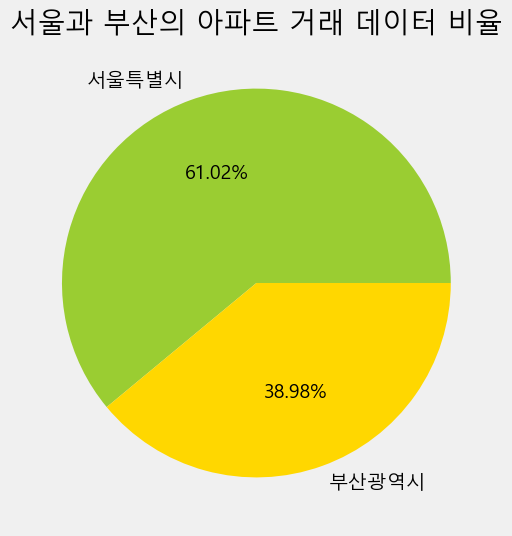

In [28]:
# matplotlib의 plt.pie()를 이용해 파이차트 그리기

color = ['yellowgreen','gold']
langs = ['서울특별시','부산광역시']

plt.figure(figsize = (8,6))
plt.pie(seoul_busan, labels=langs, colors=color, autopct='%.2f%%')
plt.title('서울과 부산의 아파트 거래 데이터 비율', size = 20)
plt.show()

In [29]:
# 연도별 count table 만들기
train_year_count = train['year'].value_counts().sort_index(ascending=True)
train_year_count

year
2008    100066
2009    127869
2010    102823
2011     98586
2012     70065
2013    109738
2014    136649
2015    181195
2016    165664
2017    123898
Name: count, dtype: int64

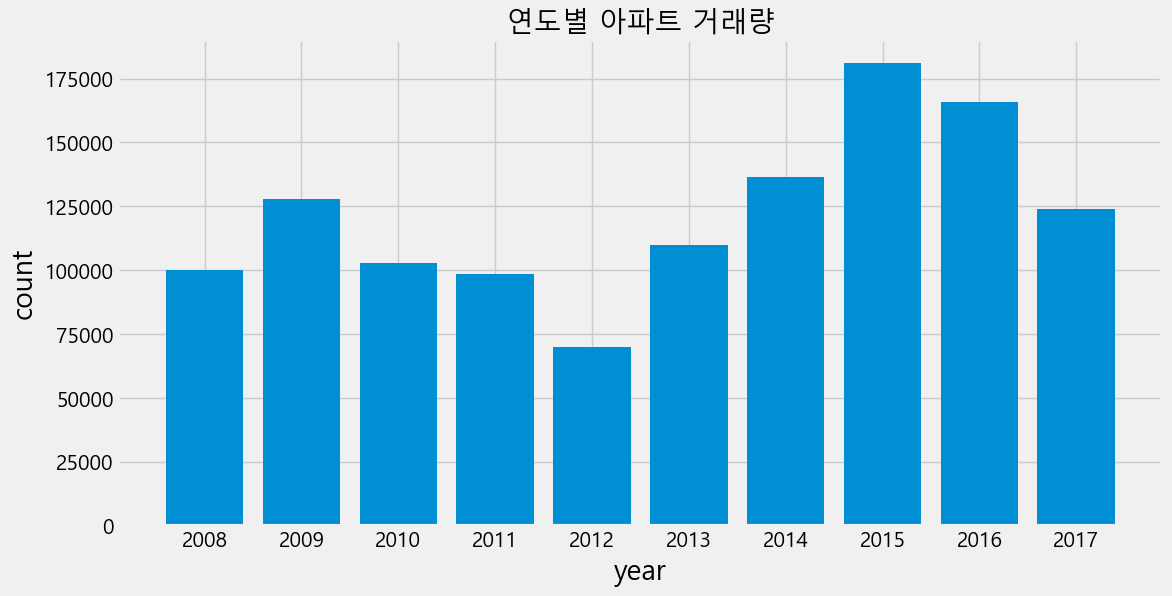

In [30]:
# matplotlib을 이용하여 연도별 아파트 거래량을 나타내기

plt.figure(figsize=(12,6))

plt.bar(train_year_count.index.astype(str), train_year_count.values)
plt.title('연도별 아파트 거래량', size = 20)

plt.xticks(size = 15)
plt.yticks(size = 15)

plt.xlabel('year', size = 20)
plt.ylabel('count',size = 20)

plt.show()